# 🔍 Тестирование детекции ценников (Grounding DINO)

Этот ноутбук позволяет:
- Загрузить изображение или папку с изображениями
- Запустить детекцию ценников через Grounding DINO
- Применить цветовой фильтр
- Увидеть результат с bounding boxes
- Сохранить размеченное изображение

In [ ]:
# Импорт библиотек
import torch
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
import shutil

# Проверка CUDA
print(f"✅ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")

In [ ]:
# 🔧 Настройки
class Config:
    # Пути
    INPUT_PATH = r"C:\Users\GGamers\Desktop\FLC\hackhatons\lenta\test"
    OUTPUT_FOLDER = r"C:\Users\GGamers\Desktop\FLC\hackhatons\lenta\test1"
    
    # Модель
    MODEL_NAME = "IDEA-Research/grounding-dino-tiny"
    TEXT_PROMPT = "price"
    
    # Пороги детекции
    BOX_THRESHOLD = 0.2
    TEXT_THRESHOLD = 0.15
    
    # Фильтры
    USE_COLOR_FILTER = True
    MIN_AREA = 500
    
    # Визуализация
    SHOW_RESULTS = True
    SAVE_ANNOTATED = True

config = Config()
print("✅ Настройки загружены")

In [ ]:
# 📦 Загрузка модели
print("Загрузка Grounding DINO...")
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoProcessor.from_pretrained(config.MODEL_NAME)
gd_model = AutoModelForZeroShotObjectDetection.from_pretrained(config.MODEL_NAME).to(device)
gd_model.eval()

print(f"✅ Модель загружена на {device}")

In [ ]:
# 🎨 Функция цветового фильтра
def filter_price_tag_colors(frame, xyxy, min_area=500):
    """Фильтр по цвету: белый/красный/желтый"""
    filtered_indices = []
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    
    for i, box in enumerate(xyxy):
        x1, y1, x2, y2 = map(int, box)
        x1, y1, x2, y2 = max(0, x1), max(0, y1), min(frame.shape[1], x2), min(frame.shape[0], y2)
        
        area = (x2 - x1) * (y2 - y1)
        if area < min_area:
            continue
        
        roi = hsv[y1:y2, x1:x2]
        roi_size = roi.shape[0] * roi.shape[1]
        
        # Красный цвет
        lower_red1 = np.array([0, 80, 100])
        upper_red1 = np.array([12, 255, 255])
        lower_red2 = np.array([150, 80, 100])
        upper_red2 = np.array([180, 255, 255])
        mask_red = cv2.bitwise_or(cv2.inRange(roi, lower_red1, upper_red1), 
                                   cv2.inRange(roi, lower_red2, upper_red2))
        
        # Белый цвет
        lower_white = np.array([0, 0, 180])
        upper_white = np.array([20, 25, 255])
        mask_white = cv2.inRange(roi, lower_white, upper_white)
        
        # Желтый цвет
        lower_yellow = np.array([20, 80, 150])
        upper_yellow = np.array([35, 255, 255])
        mask_yellow = cv2.inRange(roi, lower_yellow, upper_yellow)
        
        # Оранжевый цвет
        lower_orange = np.array([10, 80, 150])
        upper_orange = np.array([20, 255, 255])
        mask_yellow = cv2.bitwise_or(mask_yellow, cv2.inRange(roi, lower_orange, upper_orange))
        
        red_ratio = np.sum(mask_red > 0) / roi_size
        white_ratio = np.sum(mask_white > 0) / roi_size
        yellow_ratio = np.sum(mask_yellow > 0) / roi_size
        
        if (red_ratio > 0.03 and white_ratio > 0.1) or \
           (yellow_ratio > 0.05 and white_ratio > 0.1) or \
           (yellow_ratio > 0.05 and red_ratio > 0.03) or \
           red_ratio > 0.15 or white_ratio > 0.25 or yellow_ratio > 0.15:
            filtered_indices.append(i)
    
    return filtered_indices

print("✅ Функция цветового фильтра готова")

In [ ]:
# 🔍 Функция детекции (ИСПРАВЛЕНА!)
def detect_price_tags(frame, use_color_filter=True, min_area=500):
    """Grounding DINO детекция ценников"""
    image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(image_rgb)
    
    inputs = processor(images=pil_image, text=config.TEXT_PROMPT, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = gd_model(**inputs)
    
    results = processor.post_process_grounded_object_detection(
        outputs, inputs.input_ids,
        threshold=config.BOX_THRESHOLD,
        text_threshold=config.TEXT_THRESHOLD,
        target_sizes=[pil_image.size[::-1]]
    )
    
    xyxy = results[0]["boxes"].cpu().numpy()
    confidence = results[0]["scores"].cpu().numpy()
    
    # Применяем цветовой фильтр
    if use_color_filter and len(xyxy) > 0:
        filtered_idx = filter_price_tag_colors(frame, xyxy, min_area)
        xyxy = xyxy[filtered_idx]
        confidence = confidence[filtered_idx]
    
    # Фильтр по минимальной площади
    final_boxes = []
    final_conf = []
    if len(xyxy) > 0:
        for i, box in enumerate(xyxy):
            x1, y1, x2, y2 = box
            w, h = x2 - x1, y2 - y1
            if w * h >= min_area:
                final_boxes.append([x1, y1, x2, y2])
                final_conf.append(float(confidence[i]))
    
    return final_boxes, final_conf

print("✅ Функция детекции готова (ИСПРАВЛЕНА!)")

In [ ]:
# 🎯 Функция визуализации
def visualize_detections(frame, boxes, confidences, figsize=(15, 10)):
    """Визуализация детекций"""
    image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(image_rgb)
    
    colors = plt.cm.rainbow(np.linspace(0, 1, len(boxes)))
    
    for i, (box, conf, color) in enumerate(zip(boxes, confidences, colors)):
        x1, y1, x2, y2 = map(int, box)
        
        # Рисуем bounding box
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color=color, linewidth=2, label=f'Det #{i}')
        ax.add_patch(rect)
        
        # Подпись с confidence
        ax.text(x1, y1 - 10, f'Price Tag {conf:.2f}', 
               bbox=dict(facecolor=color, alpha=0.7), 
               fontsize=10, color='black', fontweight='bold')
    
    ax.set_title(f'🎯 Детекция ценников: {len(boxes)} найдено', fontsize=16, fontweight='bold')
    ax.axis('off')
    
    if len(boxes) > 1:
        ax.legend(loc='upper right', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    return fig

print("✅ Функция визуализации готова")

In [ ]:
# 📁 Функция для получения списка изображений
def get_image_files(input_path):
    """Получить список изображений из папки или файла"""
    image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.webp']
    
    input_path = Path(input_path)
    
    if input_path.is_file():
        if input_path.suffix.lower() in image_extensions:
            return [input_path]
        else:
            print(f"❌ Файл не является изображением: {input_path}")
            return []
    
    elif input_path.is_dir():
        files = [f for f in input_path.iterdir() 
                if f.suffix.lower() in image_extensions and not f.name.startswith('~')]
        return sorted(files)
    
    else:
        print(f"❌ Путь не существует: {input_path}")
        return []

print("✅ Функция получения файлов готова")

In [ ]:
# 🚀 Основная функция обработки
def process_and_annotate(image_path, save_output=True):
    """Обработка изображения и сохранение с разметкой"""
    print(f"\n{'='*60}")
    print(f"📷 Обработка: {image_path.name}")
    print(f"{'='*60}")
    
    # Чтение изображения
    frame = cv2.imread(str(image_path))
    if frame is None:
        print(f"❌ Не удалось прочитать изображение")
        return None, None, None
    
    print(f"📐 Размер: {frame.shape[1]}x{frame.shape[0]} пикселей")
    
    # Детекция
    boxes, confidences = detect_price_tags(
        frame, 
        use_color_filter=config.USE_COLOR_FILTER,
        min_area=config.MIN_AREA
    )
    
    print(f"🎯 Найдено ценников: {len(boxes)}")
    
    if len(boxes) == 0:
        print("⚠️  Детекций нет. Попробуйте снизить пороги!")
    else:
        for i, (box, conf) in enumerate(zip(boxes, confidences)):
            x1, y1, x2, y2 = map(int, box)
            print(f"   📦 Box #{i}: [{x1}, {y1}, {x2}, {y2}] (conf: {conf:.3f})")
    
    # Визуализация
    if config.SHOW_RESULTS:
        visualize_detections(frame, boxes, confidences)
    
    # Сохранение
    if save_output and config.SAVE_ANNOTATED:
        output_path = Path(config.OUTPUT_FOLDER)
        output_path.mkdir(parents=True, exist_ok=True)
        
        # Сохраняем размеченное изображение
        annotated_frame = frame.copy()
        colors = plt.cm.rainbow(np.linspace(0, 1, len(boxes)))
        
        for i, (box, conf, color) in enumerate(zip(boxes, confidences, colors)):
            x1, y1, x2, y2 = map(int, box)
            color_rgb = (int(color[0]*255), int(color[1]*255), int(color[2]*255))
            
            # Bounding box
            cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), color_rgb, 3)
            
            # Подпись
            cv2.putText(annotated_frame, f'{conf:.2f}', (x1, y1 - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, color_rgb, 2)
        
        # Сохраняем с префиксом
        output_filename = f"annotated_{image_path.name}"
        output_file = output_path / output_filename
        cv2.imwrite(str(output_file), annotated_frame)
        
        # Сохраняем оригинал
        original_copy = output_path / f"original_{image_path.name}"
        shutil.copy2(str(image_path), str(original_copy))
        
        print(f"✅ Сохранено: {output_file}")
        print(f"✅ Оригинал: {original_copy}")
        
        # Создаём YOLO разметку
        if len(boxes) > 0:
            height, width = frame.shape[:2]
            yolo_lines = []
            
            for box in boxes:
                x1, y1, x2, y2 = box
                w = x2 - x1
                h = y2 - y1
                
                x_center = (x1 + w/2) / width
                y_center = (y1 + h/2) / height
                w_norm = w / width
                h_norm = h / height
                
                yolo_lines.append(f"0 {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}")
            
            label_file = output_path / f"{image_path.stem}.txt"
            with open(label_file, 'w') as f:
                f.write('\n'.join(yolo_lines))
            
            print(f"✅ YOLO разметка: {label_file}")
    
    return frame, boxes, confidences

In [ ]:
config.USE_COLOR_FILTER = False

In [32]:
# 🔧 Настройки
class Config:
    # Пути
    INPUT_PATH = r"C:\Users\GGamers\Desktop\FLC\hackhatons\lenta\test"
    OUTPUT_FOLDER = r"C:\Users\GGamers\Desktop\FLC\hackhatons\lenta\test1"
    
    # Модель
    MODEL_NAME = "IDEA-Research/grounding-dino-tiny"
    TEXT_PROMPT = "ценник на товар"
    
    # Пороги детекции
    BOX_THRESHOLD = 0.2
    TEXT_THRESHOLD = 0.15
    
    # Фильтры
    USE_COLOR_FILTER = True
    MIN_AREA = 500
    
    # Визуализация
    SHOW_RESULTS = True
    SAVE_ANNOTATED = True

config = Config()
print("✅ Настройки загружены")

✅ Настройки загружены


📁 Найдено изображений: 5

📷 Обработка: 25_12-20_img_000030.jpg
📐 Размер: 2160x3840 пикселей
🎯 Найдено ценников: 12
   📦 Box #0: [747, 1576, 1019, 1693] (conf: 0.383)
   📦 Box #1: [64, 1441, 328, 1690] (conf: 0.357)
   📦 Box #2: [326, 3051, 585, 3262] (conf: 0.295)
   📦 Box #3: [1071, 3167, 1307, 3263] (conf: 0.280)
   📦 Box #4: [1067, 3065, 1313, 3270] (conf: 0.278)
   📦 Box #5: [1594, 3103, 1791, 3215] (conf: 0.248)
   📦 Box #6: [1591, 3006, 1806, 3221] (conf: 0.227)
   📦 Box #7: [1, 3000, 121, 3209] (conf: 0.252)
   📦 Box #8: [1435, 1587, 1671, 1732] (conf: 0.218)
   📦 Box #9: [741, 1449, 1028, 1699] (conf: 0.264)
   📦 Box #10: [1433, 1586, 1887, 1752] (conf: 0.210)
   📦 Box #11: [63, 1441, 330, 1691] (conf: 0.201)


C:\Users\GGamers\AppData\Local\Temp\ipykernel_24056\2045814975.py:29: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


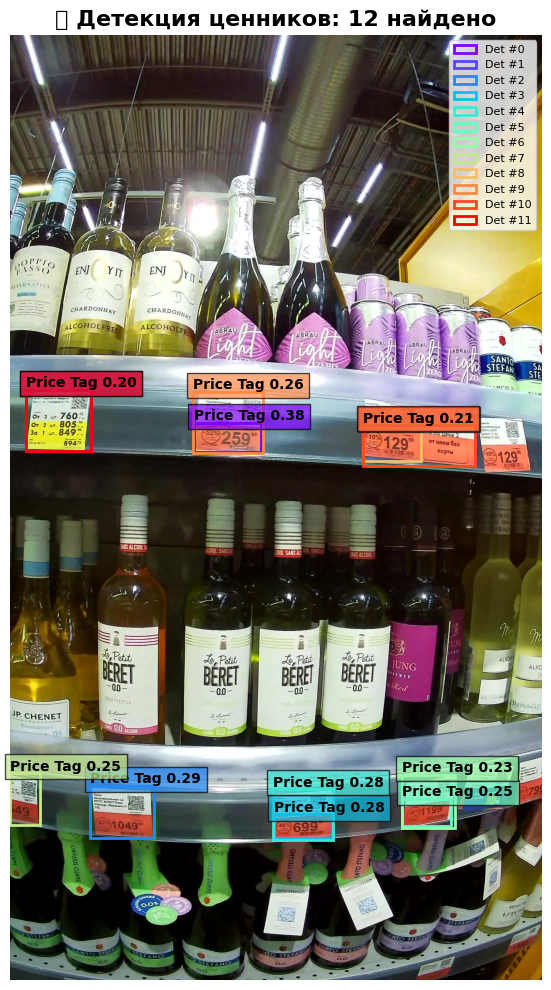

✅ Сохранено: C:\Users\GGamers\Desktop\FLC\hackhatons\lenta\test1\annotated_25_12-20_img_000030.jpg
✅ Оригинал: C:\Users\GGamers\Desktop\FLC\hackhatons\lenta\test1\original_25_12-20_img_000030.jpg
✅ YOLO разметка: C:\Users\GGamers\Desktop\FLC\hackhatons\lenta\test1\25_12-20_img_000030.txt

📷 Обработка: 25_12-20_img_000183.jpg
📐 Размер: 2160x3840 пикселей
🎯 Найдено ценников: 14
   📦 Box #0: [639, 1523, 913, 1661] (conf: 0.319)
   📦 Box #1: [67, 1516, 335, 1634] (conf: 0.308)
   📦 Box #2: [568, 3073, 829, 3271] (conf: 0.337)
   📦 Box #3: [1670, 3008, 1896, 3213] (conf: 0.296)
   📦 Box #4: [1104, 3074, 1366, 3270] (conf: 0.373)
   📦 Box #5: [197, 3018, 473, 3239] (conf: 0.293)
   📦 Box #6: [67, 1516, 335, 1635] (conf: 0.210)
   📦 Box #7: [204, 3117, 472, 3236] (conf: 0.240)
   📦 Box #8: [575, 3176, 822, 3266] (conf: 0.211)
   📦 Box #9: [1540, 1593, 1787, 1714] (conf: 0.224)
   📦 Box #10: [1532, 1470, 1792, 1722] (conf: 0.229)
   📦 Box #11: [635, 1403, 932, 1671] (conf: 0.241)
   📦 Box #12:

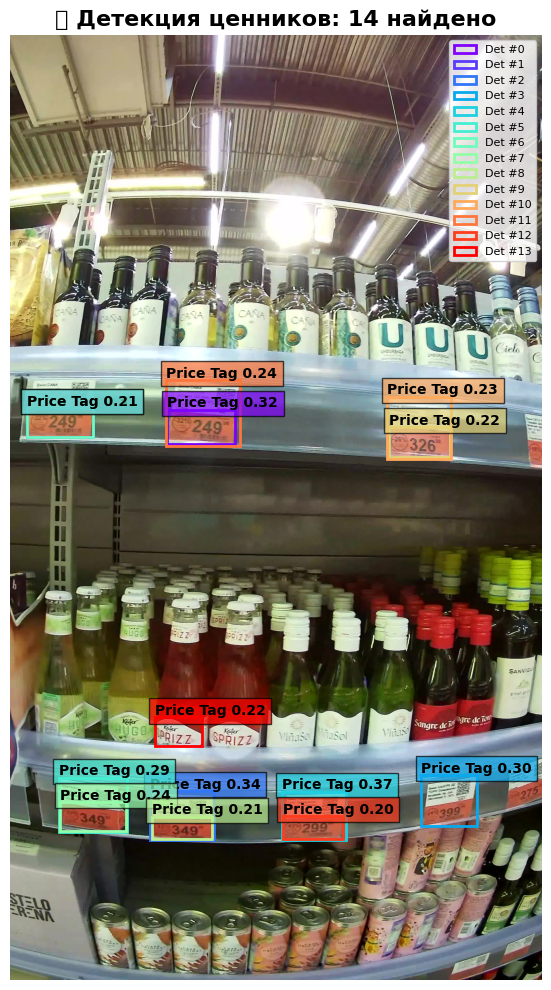

✅ Сохранено: C:\Users\GGamers\Desktop\FLC\hackhatons\lenta\test1\annotated_25_12-20_img_000183.jpg
✅ Оригинал: C:\Users\GGamers\Desktop\FLC\hackhatons\lenta\test1\original_25_12-20_img_000183.jpg
✅ YOLO разметка: C:\Users\GGamers\Desktop\FLC\hackhatons\lenta\test1\25_12-20_img_000183.txt

📷 Обработка: 25_12-20_img_000187.jpg
📐 Размер: 2160x3840 пикселей
🎯 Найдено ценников: 13
   📦 Box #0: [315, 1500, 594, 1621] (conf: 0.341)
   📦 Box #1: [1321, 3059, 1577, 3266] (conf: 0.370)
   📦 Box #2: [914, 1521, 1188, 1671] (conf: 0.308)
   📦 Box #3: [1856, 2981, 2065, 3185] (conf: 0.330)
   📦 Box #4: [795, 3083, 1058, 3279] (conf: 0.300)
   📦 Box #5: [411, 3038, 697, 3258] (conf: 0.277)
   📦 Box #6: [416, 3140, 695, 3253] (conf: 0.232)
   📦 Box #7: [910, 1398, 1198, 1677] (conf: 0.281)
   📦 Box #8: [1767, 1488, 2008, 1743] (conf: 0.247)
   📦 Box #9: [2, 2006, 247, 3266] (conf: 0.220)
   📦 Box #10: [1324, 3157, 1560, 3261] (conf: 0.205)
   📦 Box #11: [295, 1374, 609, 1633] (conf: 0.217)
   📦 Box #

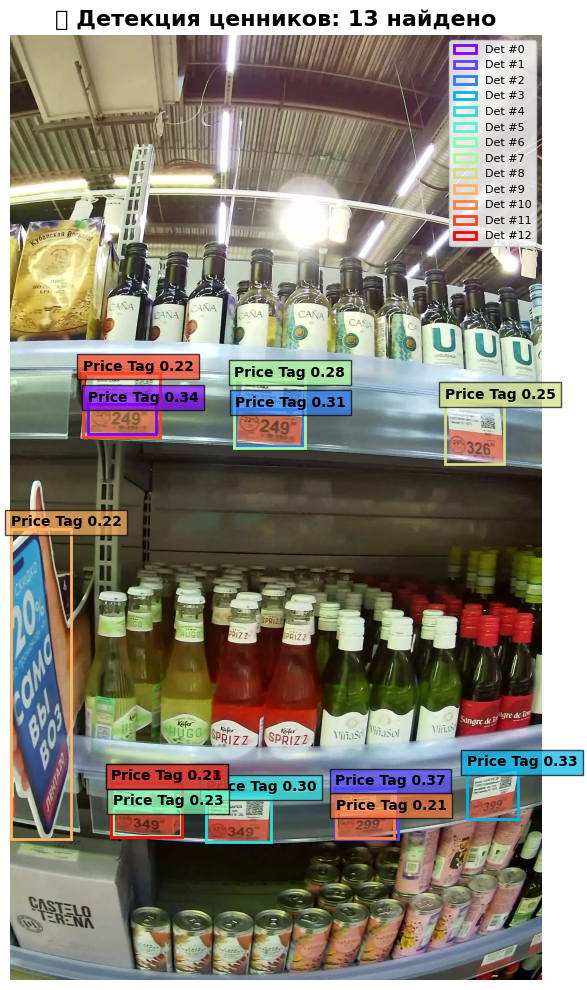

✅ Сохранено: C:\Users\GGamers\Desktop\FLC\hackhatons\lenta\test1\annotated_25_12-20_img_000187.jpg
✅ Оригинал: C:\Users\GGamers\Desktop\FLC\hackhatons\lenta\test1\original_25_12-20_img_000187.jpg
✅ YOLO разметка: C:\Users\GGamers\Desktop\FLC\hackhatons\lenta\test1\25_12-20_img_000187.txt

📷 Обработка: 25_12-20_img_000395.jpg
📐 Размер: 2160x3840 пикселей
🎯 Найдено ценников: 10
   📦 Box #0: [897, 3132, 1163, 3326] (conf: 0.427)
   📦 Box #1: [704, 1587, 992, 1716] (conf: 0.341)
   📦 Box #2: [700, 1457, 1001, 1724] (conf: 0.409)
   📦 Box #3: [700, 1457, 1001, 1724] (conf: 0.328)
   📦 Box #4: [853, 2179, 1450, 3061] (conf: 0.237)
   📦 Box #5: [898, 3133, 1163, 3326] (conf: 0.311)
   📦 Box #6: [902, 3234, 1156, 3322] (conf: 0.327)
   📦 Box #7: [262, 2141, 856, 3055] (conf: 0.213)
   📦 Box #8: [263, 2207, 854, 2799] (conf: 0.207)
   📦 Box #9: [853, 2181, 1451, 3061] (conf: 0.220)


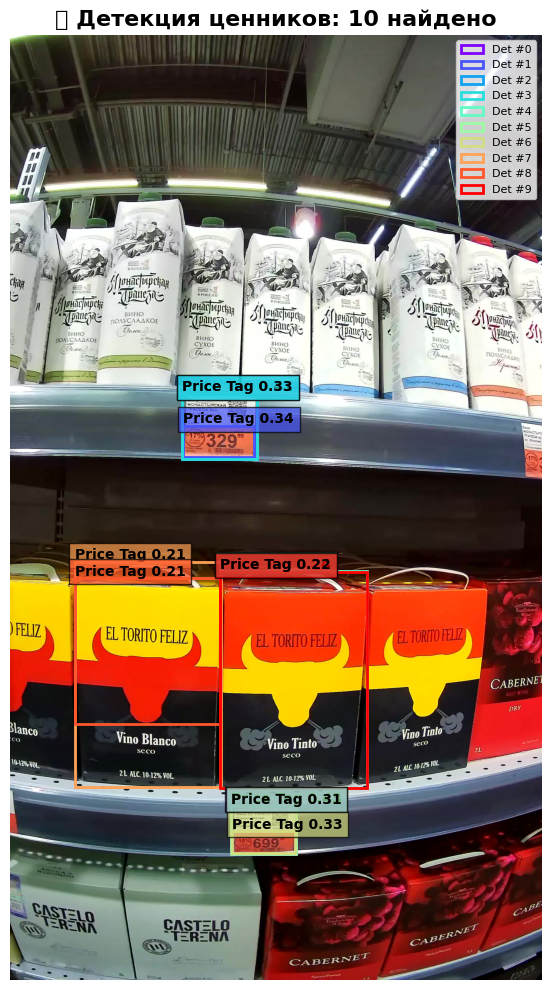

✅ Сохранено: C:\Users\GGamers\Desktop\FLC\hackhatons\lenta\test1\annotated_25_12-20_img_000395.jpg
✅ Оригинал: C:\Users\GGamers\Desktop\FLC\hackhatons\lenta\test1\original_25_12-20_img_000395.jpg
✅ YOLO разметка: C:\Users\GGamers\Desktop\FLC\hackhatons\lenta\test1\25_12-20_img_000395.txt

📷 Обработка: 26_12-20_img_000837.jpg
📐 Размер: 2160x3840 пикселей
🎯 Найдено ценников: 13
   📦 Box #0: [854, 3459, 1180, 3649] (conf: 0.361)
   📦 Box #1: [1002, 1504, 1121, 1621] (conf: 0.349)
   📦 Box #2: [1455, 3368, 1773, 3597] (conf: 0.335)
   📦 Box #3: [858, 3551, 1173, 3645] (conf: 0.282)
   📦 Box #4: [3, 3375, 316, 3604] (conf: 0.319)
   📦 Box #5: [858, 3551, 1174, 3646] (conf: 0.221)
   📦 Box #6: [986, 1310, 1394, 1675] (conf: 0.285)
   📦 Box #7: [854, 3459, 1180, 3649] (conf: 0.219)
   📦 Box #8: [1932, 1560, 2023, 1668] (conf: 0.256)
   📦 Box #9: [990, 1472, 1388, 1669] (conf: 0.271)
   📦 Box #10: [2006, 3249, 2154, 3461] (conf: 0.224)
   📦 Box #11: [1923, 1523, 2154, 1720] (conf: 0.231)
   📦 

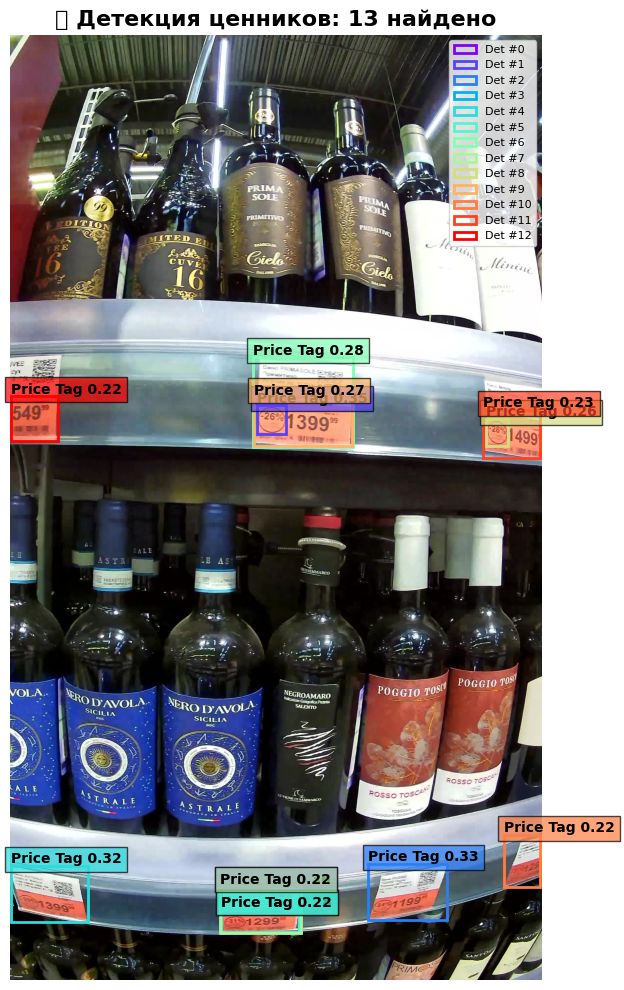

✅ Сохранено: C:\Users\GGamers\Desktop\FLC\hackhatons\lenta\test1\annotated_26_12-20_img_000837.jpg
✅ Оригинал: C:\Users\GGamers\Desktop\FLC\hackhatons\lenta\test1\original_26_12-20_img_000837.jpg
✅ YOLO разметка: C:\Users\GGamers\Desktop\FLC\hackhatons\lenta\test1\26_12-20_img_000837.txt

📊 ИТОГОВАЯ СТАТИСТИКА
Всего изображений: 5
Всего детекций: 62
Среднее детекций на изображение: 12.40

📂 Результаты сохранены в: C:\Users\GGamers\Desktop\FLC\hackhatons\lenta\test1


In [41]:
# 🎬 ЗАПУСК ОБРАБОТКИ

# Получаем список изображений
image_files = get_image_files(config.INPUT_PATH)
config.TEXT_PROMPT = (
    "orange circular price tag . "
    "orange round label . "
    "yellow rectangular price tag . "
    "shelf price label . "
    "discount badge . "
    "promotional price sticker"
)
if len(image_files) == 0:
    print("❌ Нет изображений для обработки!")
    print(f"Проверьте путь: {config.INPUT_PATH}")
else:
    print(f"📁 Найдено изображений: {len(image_files)}")
    
    # Обрабатываем каждое изображение
    results = []
    for img_path in image_files:
        frame, boxes, confidences = process_and_annotate(img_path, save_output=True)
        results.append({
            'path': img_path,
            'boxes': boxes,
            'confidences': confidences
        })
    
    # Итоговая статистика
    print(f"\n{'='*60}")
    print("📊 ИТОГОВАЯ СТАТИСТИКА")
    print(f"{'='*60}")
    total_detections = sum(len(r['boxes']) for r in results)
    print(f"Всего изображений: {len(image_files)}")
    print(f"Всего детекций: {total_detections}")
    print(f"Среднее детекций на изображение: {total_detections/len(image_files):.2f}")
    print(f"\n📂 Результаты сохранены в: {config.OUTPUT_FOLDER}")

In [ ]:
# 🔧 Быстрый тест на одном изображении
# Раскомментируйте для быстрого теста

# test_image = r"C:\Users\GGamers\Desktop\FLC\hackhatons\lenta\lenta_hack-as-branch\data\crop1.png"
# frame, boxes, confidences = process_and_annotate(Path(test_image), save_output=True)

## 💡 Советы по настройке

### Если детектирует слишком много:
- Увеличьте `BOX_THRESHOLD` до 0.3-0.4
- Увеличьте `MIN_AREA` до 1000-2000
- Включите `USE_COLOR_FILTER = True`

### Если детектирует слишком мало:
- Уменьшите `BOX_THRESHOLD` до 0.1-0.15
- Уменьшите `TEXT_THRESHOLD` до 0.1
- Уменьшите `MIN_AREA` до 200-300

### Проблемы с цветовым фильтром:
- Если ценники не красные/белые/желтые, отключите фильтр: `USE_COLOR_FILTER = False`
- Или настройте HSV диапазоны в функции `filter_price_tag_colors`